---
# Exemples de régression multilinéaire avec variables catégorielles
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "../images/startup.jpg"  width="500" />
    <div>
    <font size="1.5">Image Source: https://www.istockphoto.com/illustrations/business-clipart//</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous allons montrer un exemple de régression utilisant à la fois des variables numériques et catégorielles.

Nous allons utiliser le jeu de données startups data provenant du site de Kaggle.
Elle liste les profits de 50 compagnies jeunes-pousses (startups) uniformément réparties dans les états de New York, de la Californie et de la Floride. Elle contient les variables suivantes:
- **R\&D Spend**: dépenses investies en recherche et développement.
- **Administration**: frais d'administration.
- **Marketing Spend**: dépenses investies en marketing.
- **State**: localisation géographique (New York, California, Florida).

Les trois premières sont continues alors que la quatrième est catégorielle. On voudrait prédire les profits des compagnies en fonction de ces variables.

## Table des matières
1. Modèle général utilisé pour la régression
2. Régression linéaire simple **sans** la variable catégorielle
3. Régression linéaire simple **avec** la variable catégorielle
4. Interprétation des résultats
      1. Comparaison des profits réels et prédits
      2. Prédiction d'une valeur unique

#### Importation des librairies utilisées.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set(color_codes=True)

seed = 42
np.random.seed(seed)

ModuleNotFoundError: No module named 'sklearn'

Commençons par importer les données.

In [1]:
# Lecture du jeu de données en format CSV.
dataset = pd.read_csv("fichiers/50_Startups.csv")

# Affichage des cinq premières lignes du fichier.
dataset.head()

NameError: name 'pd' is not defined

## Modèle général utilisé pour la régression

Puisqu'il n'y a que 50 compagnies dans la base de données, ce qui est peu, on va utiliser un simple modèle multilinéaire pour son analyse :

$$
\text{Profit} \approx a_{0} + a_{1}\text{R\&D} + a_{2}\text{Administration} + a_{3}\text{Marketing} + a_{4}\text{Florida} + a_{5}\text{New York}
$$

La variable « State » contient trois catégories ; elle peut être convertie en deux variables nominales : « Florida » et « New York ». Comme les variables nominales sont mutuellement exclusives, nous n'avons pas besoin d'inclure une variable « Californie », car elle est sélectionnée par élimination lorsque « Floride » = 0 et « New York » = 0.

## Régression linéaire simple SANS la variable catégorielle

On laisse tomber la variable catégorielle « State ».

In [3]:
X = dataset[['R&D Spend', 'Administration', 'Marketing Spend']]
y = dataset['Profit']

Séparation des données en ensemble d'entraînement et de test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

Définition d'un pipeline de prétraitement des données

In [5]:
scaler = StandardScaler()
reg = LinearRegression()

pipeline_no_cat = Pipeline([
    ('scaler', scaler),
    ('model', reg)
])

Entraînement du pipeline sur les données d'entraînement uniquement et application du prétraitement sur les données d'entrainement et de test.

In [6]:
pipeline_no_cat.fit(X_train, y_train)
y_pred = pipeline_no_cat.predict(X_test)

Calcul du score, qui est la métrique R2 dans ce tutoriel.

In [7]:
score_no_cat = r2_score(y_test, y_pred)

Affichage des résultats (coefficients du modèle et score R2)

In [8]:
print("=== Modèle SANS variable catégorielle ===\n")
print("Intercept :", pipeline_no_cat.named_steps['model'].intercept_)
print("Coefficients :")

for name, coef in zip(X.columns, pipeline_no_cat.named_steps['model'].coef_):
    print(f"  {name:20s} : {coef:.3f}")

print(f"\nR2 sur test : {100*score_no_cat:.1f} %")

=== Modèle SANS variable catégorielle ===

Intercept : 115651.72050000001
Coefficients :
  R&D Spend            : 38014.736
  Administration       : -1841.476
  Marketing Spend      : 3543.386

R2 sur test : 90.0 %


Le modèle sans variable catégorielle explique 90% de la variabilité des données. On peut *simplifier* en disant qu'il explique 90% de l'information contenue dans les données.

## Régression multilinéaire AVEC la variable catégorielle

On conserve cette fois-ci la variable catégorielle « State ».

In [9]:
X = dataset[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]
y = dataset['Profit']

Séparation des données en ensemble d'entraînement et de test.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

Définition d'un pipeline de prétraitement des données. Notez qu'on identifie les deux types de variables; numériques et catégorielle.

In [11]:
num_cols = ['R&D Spend', 'Administration', 'Marketing Spend']
cat_cols = ['State']

# Il faut traiter les variables numériques et catégorielles différemment.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

pipeline_cat = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

Entraînement du pipeline 

In [12]:
pipeline_cat.fit(X_train, y_train)
y_pred_cat = pipeline_cat.predict(X_test)

Calcul du score R2.

In [13]:
score_cat = r2_score(y_test, y_pred_cat)

Affichage des résultats (coefficients du modèle et score R2)

Cette section est plus complexe à cause des multiples noms de la variable originale « State ».

In [14]:
# Récupération des noms de colonnes après transformation
ohe = pipeline_cat.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = num_cols + list(cat_features)

coefs = pipeline_cat.named_steps['model'].coef_

print("=== Modèle AVEC variable catégorielle ===\n")
print("Intercept :", pipeline_cat.named_steps['model'].intercept_)
print("\nCoefficients :")
for name, coef in zip(feature_names, coefs):
    print(f"  {name:20s} : {coef:.3f}")

print(f"\nR2 sur test : {100*score_cat:.1f} %")

=== Modèle AVEC variable catégorielle ===

Intercept : 115320.8719258588

Coefficients :
  R&D Spend            : 38102.269
  Administration       : -1864.754
  Marketing Spend      : 3386.176
  State_Florida        : 938.793
  State_New York       : 6.988

R2 sur test : 89.9 %


Le modèle incluant une variable catégorielle explique 89,9 % de la variabilité des données. 

## Interprétation des résultats

Les deux modèles ont une valeur de R² presque identique. Cela signifie que la variable « State » a un effet négligeable sur les profits des startups.

On remarque également que, pour les deux modèles, les variables les plus importantes (en valeur absolue) sont :
1. Les dépenses en R&D (+) ;
2. Les dépenses en marketing (+) ;
3. Les charges administratives (-) ;

Les dépenses en R&D et en marketing augmentent les profits, tandis que les charges administratives les réduisent. C'est logique !

**Important** : les valeurs affichées des coefficients correspondent aux variables normalisées ! Il ne s'agit pas des valeurs correspondant aux variables originales. On peut obtenir ces dernières avec scikit-learn, mais on le fait rarement, car l'analyse des valeurs des coefficients relève davantage des statistiques. En apprentissage automatique, on s'intéresse davantage aux performances des modèles (pour pouvoir en comparer plusieurs entre eux) ainsi qu'aux variables les plus importantes.

<p>&nbsp;</p>
<div align="center">
    <img src= "../images/professor-in-green.jpeg"  width="300" />
    <div>
    <font size="1.5">Image Source: https://www.istockphoto.com/illustrations/business-clipart//</font>
    </div>
</div>
<p>&nbsp;</p>


### Comparaison des profits réels et prédits

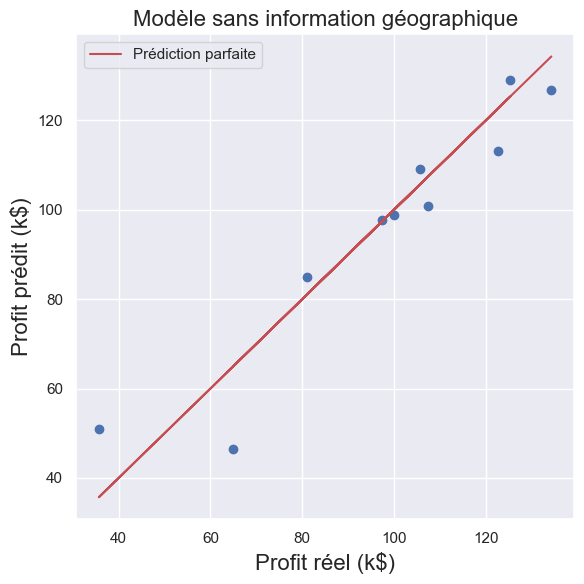

In [15]:
# Conversion en k$
y_test = y_test / 1000
y_pred = y_pred / 1000

fig = plt.figure(figsize=(6, 6))
plt.plot(y_test, y_pred, "o")
plt.plot(y_test, y_test, "-r", label="Prédiction parfaite")
plt.title("Modèle sans information géographique", fontsize=16)
plt.xlabel("Profit réel (k$)", fontsize=16)
plt.ylabel("Profit prédit (k$)", fontsize=16)
plt.legend()
fig.tight_layout()
plt.show()

Le modèle est d'autant meilleur que les profits sont élevés.

### Prédiction pour une seule statup

Jusqu'à maintenant, on a effectué des prédictions sur les ensembles d'entraînement et de test qui contenaient les données de plusieurs compagnies. Voici comment le faire pour une compagnie à la fois.

Quel serait le profit d'une compagnie californienne ayant investi $50,000 \$$ en R&D, $150,000 \$$ en administration et $200,000 \$$ en marketing ?

#### Modèle SANS la variable catégorielle « State »

In [16]:
X0 = pd.DataFrame(
    {
        "R&D Spend": 50000,
        "Administration": 150000,
        "Marketing Spend": 200000,
    },
    index=[0],
)

# Prédiction du profit
y0 = pipeline_no_cat.predict(X0)

profit = y0.item()
print(f"\t Profits = {profit/1000:.1f} k$")

	 Profits = 90.3 k$


#### Modèle AVEC la variable catégorielle « State »

In [17]:
X0 = pd.DataFrame(
    {
        "R&D Spend": 50000,
        "Administration": 150000,
        "Marketing Spend": 200000,
        "State": "California",
    },
    index=[0],
)

# Prédiction du profit
y0 = pipeline_cat.predict(X0)

profit = y0.item()
print(f"\t Profits = {profit/1000:.1f} k$")

	 Profits = 90.0 k$


On voit que les profits prédits varient très peu entre les deux modèles. La différence de $300 \$$ est négligeable!